In [2]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# load the dataset
df = pd.read_csv(r'imblanced_dataset - imblanced_dataset.csv')

In [4]:
# check the first 5 rows of the dataset
df.head()

,customer_id,age,income,city,education,experience_years,employment_type,credit_score,loan_amount,default
0,101872,33.0,59985.0,Jaipur,Graduate,7.0,Salaried,790.0,NaN,No
1,100356,25.0,63499.0,Delhi,Postgraduate,4.0,Salaried,666.0,75592.0,No
2,101342,35.0,48128.0,Mumbai,Postgraduate,9.0,Business,689.0,36649.0,No
3,100910,57.0,109811.0,Mumbai,Graduate,31.0,Salaried,742.0,129423.0,No
4,101297,44.0,138290.0,Hyderabad,10th,17.0,Salaried,764.0,NaN,No


In [5]:
# check the last 5 rows of the dataset
df.tail()


,customer_id,age,income,city,education,experience_years,employment_type,credit_score,loan_amount,default
1995,101136,45.0,70174.0,Mumbai,Graduate,27.0,Salaried,721.0,NaN,No
1996,101302,45.0,NaN,Kolkata,12th,20.0,Contract,712.0,24962.0,No
1997,100865,29.0,68859.0,Jaipur,10th,11.0,Salaried,824.0,65018.0,No
1998,101469,23.0,42834.0,Jaipur,Graduate,5.0,Salaried,611.0,38677.0,No
1999,101132,39.0,53875.0,Delhi,Graduate,12.0,Unemployed,730.0,47666.0,No


In [ ]:
# check the number of rows and columns in the dataset
print("Number of rows in the dataset:", df.shape[0])
print("="*120)
print("Number of columns in the dataset:", df.shape[1])


Number of rows in the dataset: 2000
Number of columns in the dataset: 10


In [12]:
# Check the all columns in the dataset
for column in df.columns:
    print(column)
    print("-" * 120)

customer_id
------------------------------------------------------------------------------------------------------------------------
age
------------------------------------------------------------------------------------------------------------------------
income
------------------------------------------------------------------------------------------------------------------------
city
------------------------------------------------------------------------------------------------------------------------
education
------------------------------------------------------------------------------------------------------------------------
experience_years
------------------------------------------------------------------------------------------------------------------------
employment_type
------------------------------------------------------------------------------------------------------------------------
credit_score
---------------------------------------------------------------------

In [10]:
# check missing values in the dataset
print("Total missing values in the dataset:", df.isnull().sum().sum())
print("="*120)
for column in df.columns:
    print(f"Missing values in column '{column}': {df[column].isnull().sum()}")
    print("-" * 120)

Total missing values in the dataset: 352
Missing values in column 'customer_id': 0
------------------------------------------------------------------------------------------------------------------------
Missing values in column 'age': 46
------------------------------------------------------------------------------------------------------------------------
Missing values in column 'income': 60
------------------------------------------------------------------------------------------------------------------------
Missing values in column 'city': 35
------------------------------------------------------------------------------------------------------------------------
Missing values in column 'education': 30
------------------------------------------------------------------------------------------------------------------------
Missing values in column 'experience_years': 41
------------------------------------------------------------------------------------------------------------------

In [13]:
# check the data types of each column in the dataset
print("Data types of each column in the dataset:")
for column in df.columns:
    print(f"Column '{column}': {df[column].dtype}")
    print("-" * 120)

Data types of each column in the dataset:
Column 'customer_id': int64
------------------------------------------------------------------------------------------------------------------------
Column 'age': float64
------------------------------------------------------------------------------------------------------------------------
Column 'income': float64
------------------------------------------------------------------------------------------------------------------------
Column 'city': object
------------------------------------------------------------------------------------------------------------------------
Column 'education': object
------------------------------------------------------------------------------------------------------------------------
Column 'experience_years': float64
------------------------------------------------------------------------------------------------------------------------
Column 'employment_type': object
----------------------------------------

In [19]:
# Check duplicate rows in the dataset
duplicate_rows = df[df.duplicated(keep=False)]
print("Number of duplicate rows in the dataset:", duplicate_rows.shape[0])
print("="*120)
print("Duplicate rows in the dataset:")
print(duplicate_rows)

Number of duplicate rows in the dataset: 24
Duplicate rows in the dataset:
      customer_id    age    income       city     education  experience_years  \
186        101450   35.0   43809.0       Pune  Postgraduate              11.0   
406        101717   38.0  327351.0    Chennai  Postgraduate              11.0   
445        100580   46.0  144687.0  Hyderabad  Postgraduate              21.0   
480        101841   34.0   39231.0    Chennai  Postgraduate               8.0   
579        101780  120.0   52457.0     Mumbai      Graduate               5.0   
624        101010   30.0   42445.0  Hyderabad          12th               5.0   
657        101841   34.0   39231.0    Chennai  Postgraduate               8.0   
767        101450   35.0   43809.0       Pune  Postgraduate              11.0   
804        100415   38.0   96259.0     Mumbai      Graduate              19.0   
944        101010   30.0   42445.0  Hyderabad          12th               5.0   
978        101817   18.0   44558.0

In [20]:
# remove duplicate rows from the dataset and keep the first occurrence
df = df.drop_duplicates(keep='first')

In [21]:
# check duplicate rows again after removing duplicates
duplicate_rows_after_removal = df[df.duplicated(keep=False)]
print("Number of duplicate rows in the dataset after removal:", duplicate_rows_after_removal.shape[0])
print("="*120)
print("Duplicate rows in the dataset after removal:")
print(duplicate_rows_after_removal)

Number of duplicate rows in the dataset after removal: 0
Duplicate rows in the dataset after removal:
Empty DataFrame
Columns: [customer_id, age, income, city, education, experience_years, employment_type, credit_score, loan_amount, default]
Index: []


In [22]:
# Check the shape after removing duplicates
print("Shape of the dataset after removing duplicates:", df.shape)

Shape of the dataset after removing duplicates: (1988, 10)


In [26]:
# check missing values in the dataset
missing_values = df.isnull().sum()
print("Total missing values in the dataset:", missing_values.sum())
print("="*120)
for column in df.columns:
    if missing_values[column] > 0:
        print(f"Column '{column}' has {missing_values[column]} missing values.")
        print("-" * 120)

Total missing values in the dataset: 349
Column 'age' has 45 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'income' has 59 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'city' has 35 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'education' has 30 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'experience_years' has 40 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'employment_type' has 35 missing values.
-------------------------------------------------------------------------------------------------------

In [32]:
# take a numaric column  
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
for column in numeric_columns:
    print(f"Column '{column}' has {df[column].isnull().sum()} missing values.")
    print("-" * 120)

Column 'customer_id' has 0 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'age' has 45 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'income' has 59 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'experience_years' has 40 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'credit_score' has 55 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'loan_amount' has 50 missing values.
------------------------------------------------------------------------------------------------------------------------


In [33]:
# Take a categorical column
categorical_columns = df.select_dtypes(include=[object]).columns.tolist()
for column in categorical_columns:
    print(f"Column '{column}' has {df[column].isnull().sum()} missing values.")
    print("-" * 120)

Column 'city' has 35 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'education' has 30 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'employment_type' has 35 missing values.
------------------------------------------------------------------------------------------------------------------------
Column 'default' has 0 missing values.
------------------------------------------------------------------------------------------------------------------------


In [34]:
# Handle missing values in the dataset
# for numeric columns, we can fill missing values with the mean of the column
for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        mean_value = df[column].mean()
        df[column].fillna(mean_value, inplace=True)
        print(f"Filled missing values in column '{column}' with mean value: {mean_value}")
        print("-" * 120)

Filled missing values in column 'age' with mean value: 36.007720020586724
------------------------------------------------------------------------------------------------------------------------
Filled missing values in column 'income' with mean value: 66210.16277864178
------------------------------------------------------------------------------------------------------------------------
Filled missing values in column 'experience_years' with mean value: 13.431211498973306
------------------------------------------------------------------------------------------------------------------------
Filled missing values in column 'credit_score' with mean value: 697.5737196068287
------------------------------------------------------------------------------------------------------------------------
Filled missing values in column 'loan_amount' with mean value: 52995.96904024768
--------------------------------------------------------------------------------------------------------------------

C:\Users\deore\AppData\Local\Temp\ipykernel_27248\1029821413.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mean_value, inplace=True)


In [35]:
# Handle missing values in the dataset
# For categorical columns, we can fill missing values with the mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()[0]
        df[column].fillna(mode_value, inplace=True)
        print(f"Filled missing values in column '{column}' with mode value: {mode_value}")
        print("-" * 120)

Filled missing values in column 'city' with mode value: Hyderabad
------------------------------------------------------------------------------------------------------------------------
Filled missing values in column 'education' with mode value: Graduate
------------------------------------------------------------------------------------------------------------------------
Filled missing values in column 'employment_type' with mode value: Salaried
------------------------------------------------------------------------------------------------------------------------


C:\Users\deore\AppData\Local\Temp\ipykernel_27248\181854814.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)


In [38]:
# Check missing values in the dataset
print("Total missing values in the dataset:", df.isnull().sum().sum())
print("="*120)

Total missing values in the dataset: 0


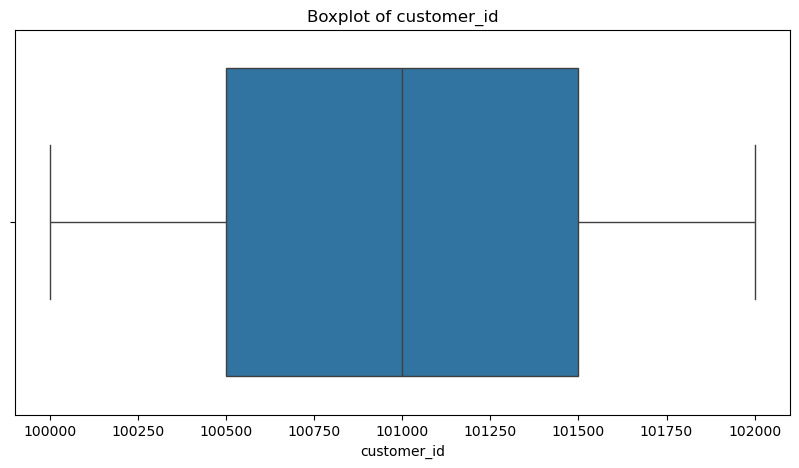

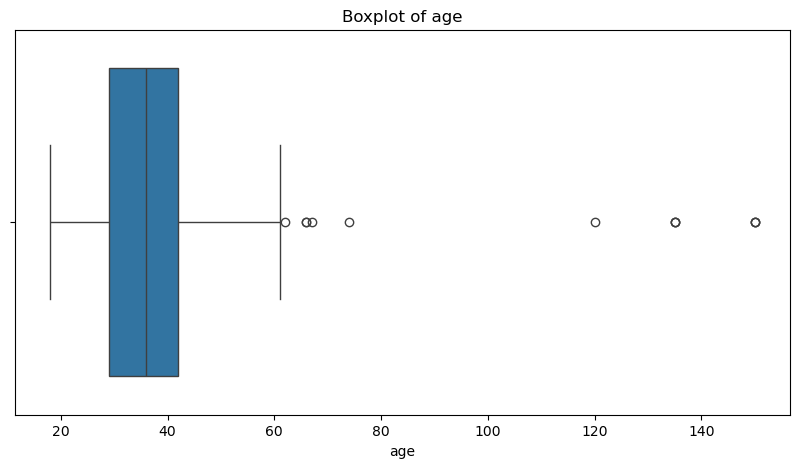

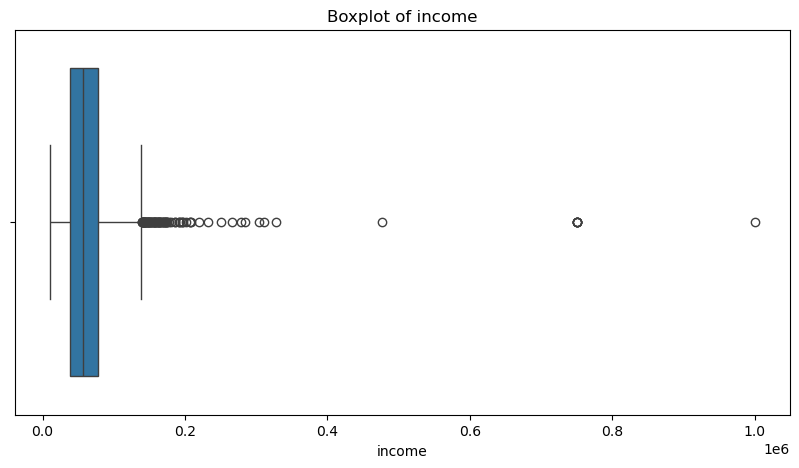

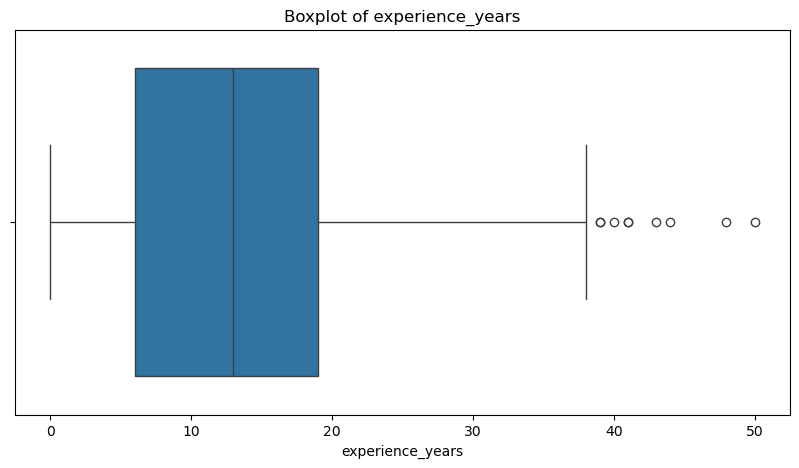

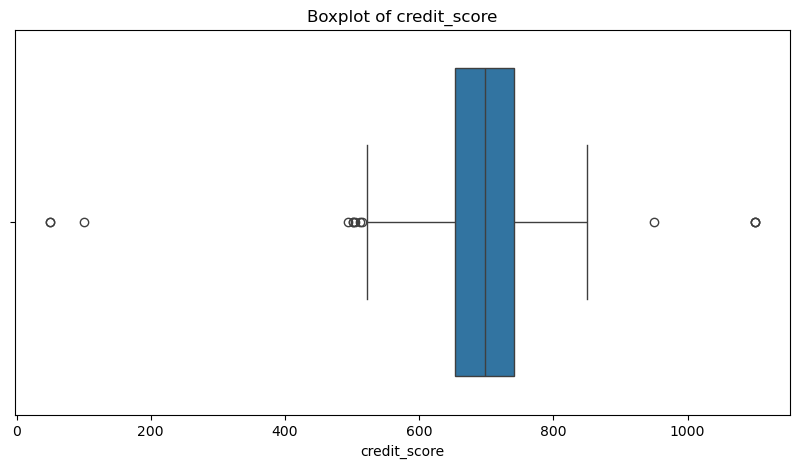

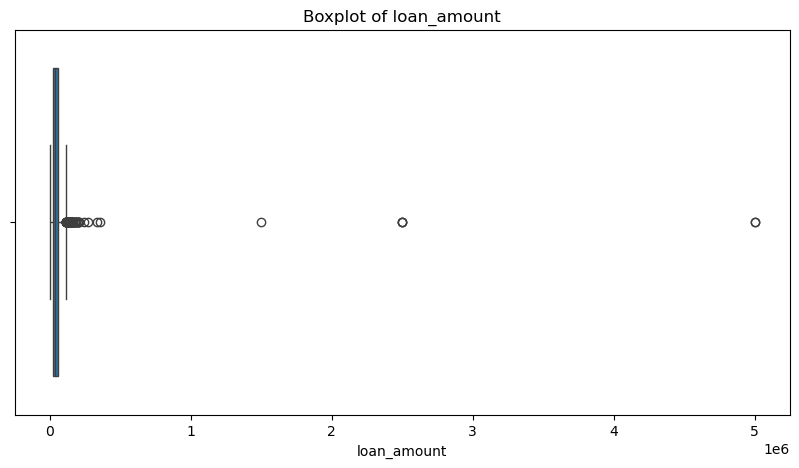

In [37]:
# Check outlier using boxplot for numeric columns
for column in numeric_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()  

In [39]:
# Handle the outliers in the dataset using IQR method and clipping
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    print(f"Handled outliers in column '{column}' using IQR method and clipping.")
    print("-" * 120)

Handled outliers in column 'customer_id' using IQR method and clipping.
------------------------------------------------------------------------------------------------------------------------
Handled outliers in column 'age' using IQR method and clipping.
------------------------------------------------------------------------------------------------------------------------
Handled outliers in column 'income' using IQR method and clipping.
------------------------------------------------------------------------------------------------------------------------
Handled outliers in column 'experience_years' using IQR method and clipping.
------------------------------------------------------------------------------------------------------------------------
Handled outliers in column 'credit_score' using IQR method and clipping.
------------------------------------------------------------------------------------------------------------------------
Handled outliers in column 'loan_amount' u

In [ ]:
# check the outliers in the categorical columns using frequency encoding and clipping 
for column in categorical_columns:
    frequency_encoding = df[column].value_counts(normalize=True)
    lower_bound = frequency_encoding.quantile(0.05)
    upper_bound = frequency_encoding.quantile(0.95)
    df[column] = df[column].apply(lambda x: x if lower_bound <= frequency_encoding[x] <= upper_bound else np.nan)
    df[column].fillna(df[column].mode()[0], inplace=True)
    

In [ ]:
# Handle the outliers in the categorical columns using frequency encoding and clipping
for columns in categorical_columns